# $\text{Eksperimen untuk Tautan Hopf}$

/tmp/ipykernel_314/2914158936.py:78: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  IQFT = QFT(


========== Betti Number Estimation ==========
Kombinasi: [5, 5, 5]
Trace Gibbs: 4.027133395960007
Probabilitas: 0.9932803822784544
Betti global: 4.000072599025486
Error: 7.25990254863973e-05


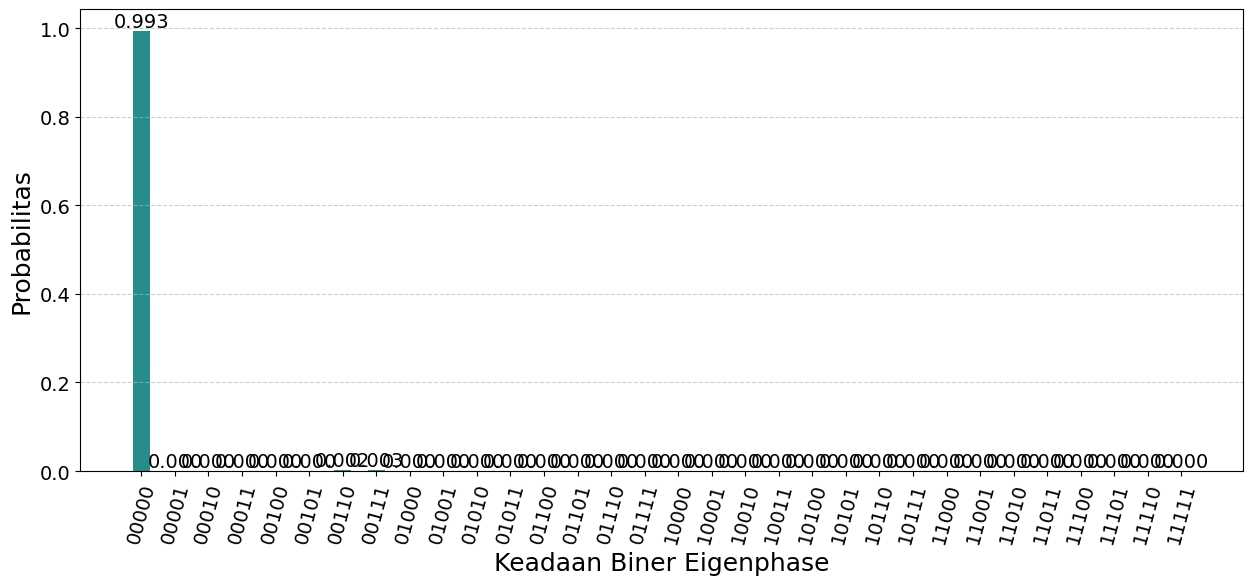

In [ ]:
# ==========================
# Identity Padding Function
# ==========================
import numpy as np

def identity_padding(matrix):
    # Dimensi awal matriks
    n = matrix.shape[0]

    # Mencari pangkat dua terdekat
    N = 2**(int(np.ceil(np.log2(n))))

    # Jika matriks sudah 2^n x 2^n
    pad = N - n
    if pad == 0:
        return matrix

    # Matriks 0 berukuran N x N
    matrix_padding = np.zeros((N, N))

    # Blok utama diisi dengan matriks utama
    matrix_padding[:n, :n] = matrix

    # Identity padding untuk blok sisa
    matrix_padding[n:, n:] = np.eye(pad)

    return matrix_padding

# =====================
# Gibbs State Function
# =====================
import numpy as np
from scipy.linalg import expm

def gibbs_state(matrix, mu):
    exp_matrix = expm(-mu * matrix)
    return exp_matrix / np.trace(exp_matrix)

# =====================
# Trace of Gibbs State
# =====================
def trace(matrix, mu):
    exp_matrix = expm(-mu * matrix)
    return np.trace(exp_matrix)

# ==========================
# Unitary Operator Function
# ==========================
from scipy.linalg import expm

def unitary_operator(matrix, time):
    return expm(-1j * matrix * time)

# ===============================
# Quantum Phase Estimation (QPE)
# ===============================
from qiskit.circuit.library import UnitaryGate, QFT

def QuantumPhaseEstimation(quantum_circuit, unitary_matrix, n_control):
    # Menentukan total qubit
    U_gate = UnitaryGate(unitary_matrix.data)
    n_target = U_gate.num_qubits
    total_qubit = n_control + n_target

    # Hadamard untuk qubit kontrol
    for i in range(n_control):
        quantum_circuit.h(i)

    # Menerapkan iterasi Controlled-U^(2^(k))
    target_qubits = list(range(n_control, total_qubit))
    for k in range(n_control):
        controlled_U = U_gate.power(2**k).control(1)
        quantum_circuit.append(controlled_U, [k] + target_qubits)

    # Menerapkan IQFT bawaan Qiskit
    quantum_circuit.barrier()

    IQFT = QFT(
        num_qubits=n_control,
        inverse=True
    )

    quantum_circuit.append(IQFT, range(n_control))

# ===========================
# Matriks Khovanov Laplacian
# ===========================
import numpy as np
from scipy.linalg import block_diag

# Matriks diferensial d^0
d0 = np.array([
    [1, 0, 0, 0],
    [0, 1, 1, 0],
    [1, 0, 0, 0],
    [0, 1, 1, 0]
], dtype=float)

# Matriks diferensial d^1
d1 = np.array([
    [0, 0, 0, 0],
    [1, 0, -1, 0],
    [1, 0, -1, 0],
    [0, 1, 0, -1]
], dtype=float)

# Definisikan Khovanov Laplacian ke-0
Delta0 = d0.conj().T @ d0

# Definisikan Khovanov Laplacian ke-1
Delta1 = d1.conj().T @ d1 + d0 @ d0.conj().T

# Definisikan matriks Laplacian ke-2
Delta2 = d1 @ d1.conj().T

# Jumlah langsung semua Laplacian (Laplacian global)
Delta = block_diag(Delta0, Delta1, Delta2)

# =================
# Simulasi Kuantum
# =================
import numpy as np
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix
from qiskit import QuantumCircuit, transpile

# Bantalan identitas untuk Laplacian global
Delta_pad = identity_padding(Delta)

# Variasi Parameter
X = [5, 5, 5]

# Membentuk keadaan Gibbs
mu = X[0]
keadaan_gibbs = gibbs_state(Delta_pad, mu)

# Membantuk operator uniter
t = X[1]
operator_uniter = unitary_operator(Delta_pad, t)

# Inisialisasi
qubit_resolusi = X[2]
qubit_sistem = int(np.log2(Delta_pad.shape[0]))
total_qubits = qubit_resolusi + qubit_sistem

# Matriks densitas untuk qubit resolusi
rho_resolusi = np.zeros((2**qubit_resolusi, 2**qubit_resolusi), dtype=complex)
rho_resolusi[0,0] = 1

# Matriks densitas untuk qubit total
rho_total = np.kron(keadaan_gibbs, rho_resolusi)
rho = DensityMatrix(rho_total)

# Sirkuit kuantum berbasis matriks densitas
qc = QuantumCircuit(total_qubits)
qc.set_density_matrix(rho)

# Menerapkan Quantum Phase Estimation
QuantumPhaseEstimation(qc, operator_uniter, qubit_resolusi)
qc.save_density_matrix()

# Simulasi
sim = AerSimulator(method="density_matrix")
qct = transpile(qc, sim)
result = sim.run(qct).result()
final_rho = result.data(0)['density_matrix']

# ========================
# Estimasi Bilangan Betti
# ========================
import numpy as np
from qiskit.quantum_info import DensityMatrix, partial_trace

# Partial trace
rho_total = DensityMatrix(final_rho)
rho_phase = partial_trace(rho_total, list(np.arange(qubit_resolusi, total_qubits)))

# Perhitungan bilangan Betti
chain_dimension = trace(Delta_pad, mu)
probabilities = np.real(np.diag(rho_phase.data))
probability_zero = probabilities[0]
kernel_dimension = chain_dimension * probability_zero

print("========== Betti Number Estimation ==========")
print(f"Kombinasi: {X}")
print(f'Trace Gibbs: {chain_dimension}')
print(f"Probabilitas: {probability_zero}")
print(f"Betti global: {kernel_dimension}")
print(f"Error: {kernel_dimension - 4}")

# ======================
# Bar Plot Probabilitas
# ======================
import matplotlib.pyplot as plt

bitstrings = []
probability = []
for i, p in enumerate(probabilities):
    bitstrings.append(format(i, f'0{qubit_resolusi}b'))
    probability.append(p)

# Plotting
plt.figure(figsize=(15, 6))
bars = plt.bar(bitstrings, probability, width=0.5, color='#298c8c')

plt.xlabel("Keadaan Biner Eigenphase", fontsize=18)
plt.ylabel("Probabilitas", fontsize=18)

plt.xticks(rotation=75, fontsize=14)
plt.yticks(fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.6)

# Menampilkan angka probabilitas di atas bar
for bar, prob in zip(bars, probability):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        prob,
        f"{prob:.3f}",
        ha='center',
        va='bottom',
        fontsize=14
    )

# plt.savefig('distribusi_probabilitas_hopf.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
matrix = np.array([
    [3, 3, 3, 3, 3, 3],
    [3, 3, 3, 3, 3, 3],
    [3, 3, 3, 3, 3, 3],
    [3, 3, 3, 3, 3, 3],
    [3, 3, 3, 3, 3, 3],
    [3, 3, 3, 3, 3, 3]
])

matrix_pad = identity_padding(matrix)
print(matrix_pad)

[[   3.    3.    3.    3.    3.    3.    0.    0.]
 [   3.    3.    3.    3.    3.    3.    0.    0.]
 [   3.    3.    3.    3.    3.    3.    0.    0.]
 [   3.    3.    3.    3.    3.    3.    0.    0.]
 [   3.    3.    3.    3.    3.    3.    0.    0.]
 [   3.    3.    3.    3.    3.    3.    0.    0.]
 [   0.    0.    0.    0.    0.    0. 1000.    0.]
 [   0.    0.    0.    0.    0.    0.    0. 1000.]]


In [ ]:
print(trace(Delta, mu))
print(trace(Delta_pad, mu))

4.0013423006523094
4.074604856207245


In [ ]:
# from google.colab import files

# files.download('distribusi_probabilitas_hopf.png')

# $\text{Uji - Uji pada Matriks}$

#### $\text{Uji Hermitian}$ $\texttt{Delta_pad}$

In [ ]:
np.allclose(Delta_pad, Delta_pad.conj().T)

In [ ]:
eigenvalue1, _ = np.linalg.eigh(Delta_pad)
print(eigenvalue1)

#### $\text{Uji Matriks Densitas}$ $\texttt{keadaan_gibbs}$

In [ ]:
np.allclose(keadaan_gibbs, keadaan_gibbs.conj().T)

In [ ]:
eigenvalue2, _ = np.linalg.eigh(keadaan_gibbs)
print(eigenvalue2)

In [ ]:
np.trace(keadaan_gibbs)

#### $\text{Uji Operator Uniter}$ $\texttt{operator_uniter}$

In [ ]:
np.allclose(operator_uniter @ operator_uniter.conj().T, np.eye(operator_uniter.shape[0]))

# $\text{Analisis Data Simulasi}$

In [ ]:
import numpy as np

# ==========================================
# Fungsi simulasi untuk satu parameter X
# ==========================================
def estimasi_betti(mu, t, qubit_resolusi):
    # Bantalan identitas untuk Laplacian global
    Delta_pad = identity_padding(Delta)

    # Membentuk keadaan Gibbs
    keadaan_gibbs = gibbs_state(Delta_pad, mu)

    # Membentuk operator uniter
    operator_uniter = unitary_operator(Delta_pad, t)

    # Inisialisasi qubit
    qubit_sistem = int(np.log2(Delta_pad.shape[0]))
    total_qubits = qubit_resolusi + qubit_sistem

    # Matriks densitas untuk qubit resolusi
    rho_resolusi = np.zeros(
        (2**qubit_resolusi, 2**qubit_resolusi),
        dtype=complex
    )
    rho_resolusi[0, 0] = 1

    # Matriks densitas total
    rho_total = np.kron(keadaan_gibbs, rho_resolusi)
    rho = DensityMatrix(rho_total)

    # Sirkuit kuantum
    qc = QuantumCircuit(total_qubits)
    qc.set_density_matrix(rho)

    # Quantum Phase Estimation
    QuantumPhaseEstimation(qc, operator_uniter, qubit_resolusi)
    qc.save_density_matrix()

    # Simulasi
    sim = AerSimulator(method="density_matrix")
    qct = transpile(qc, sim)
    result = sim.run(qct).result()
    final_rho = result.data(0)['density_matrix']

    # Estimasi bilangan Betti
    rho_total = DensityMatrix(final_rho)
    rho_phase = partial_trace(
        rho_total,
        list(np.arange(qubit_resolusi, total_qubits))
    )
    chain_dimension = trace(Delta_pad, mu)
    probabilities = np.real(np.diag(rho_phase.data))
    probability_zero = probabilities[0]
    kernel_dimension = chain_dimension * probability_zero
    error = kernel_dimension - 4

    return {
        "mu": mu,
        "t": t,
        "k": qubit_resolusi,
        "trace_gibbs": chain_dimension,
        "probabilitas": probability_zero,
        "betti_global": kernel_dimension,
        "error": error
    }

# ==========================================
# Variasi parameter FLFD Tereduksi
# ==========================================
data = [
    [0, 2, 3],
    [1, 2, 3],
    [2, 2, 3],
    [3, 2, 3],
    [4, 2, 3],

    [2, 0, 3],
    [2, 1, 3],
    [2, 2, 3],
    [2, 3, 3],
    [2, 4, 3],

    [2, 2, 1],
    [2, 2, 2],
    [2, 2, 3],
    [2, 2, 4],
    [2, 2, 5],

    [0, 0, 3],
    [1, 1, 3],
    [2, 2, 3],
    [3, 3, 3],
    [4, 4, 3],

    [0, 2, 1],
    [1, 2, 2],
    [2, 2, 3],
    [3, 2, 4],
    [4, 2, 5],

    [2, 0, 1],
    [2, 1, 2],
    [2, 2, 3],
    [2, 3, 4],
    [2, 4, 5],

    [0, 0, 1],
    [1, 1, 2],
    [2, 2, 3],
    [3, 3, 4],
    [4, 4, 5]
]

data_simulasi = []
for order, value in enumerate(data):
    print(f"Running: mu={value[0]}, t={value[1]}, k={value[2]} ===> {order + 1}/{len(data)}")
    out = estimasi_betti(value[0], value[1], value[2])
    data_simulasi.append(out)

In [ ]:
import pandas as pd

data_analisis = pd.DataFrame(data_simulasi)
data_analisis

In [ ]:
hasil_spesifik = data_analisis[
    (data_analisis['mu'] == 4) &
    (data_analisis['t'] == 2) &
    (data_analisis['k'] == 3)
]

hasil_spesifik

#### $\text{Analisis Deskriptif}$

In [ ]:
data_analisis.describe()

Data sudah seimbang dengan semua feature memiliki 35 sample

In [ ]:
data_analisis[data_analisis["error"] <= 0.0001]

Nilai $\mu$ tertinggi dan nilai $k$ tertinggi menghasilkan estimasi bilangan Betti paling akurat

In [ ]:
data_analisis.groupby("mu")["error"].mean()

Secara kasar, semakin tinggi nilai $\mu$, maka error estimasi bilangan Betti $E$ akan semakin kecil

In [ ]:
data_analisis.groupby("t")["error"].mean()

Secara kasar, semaking tinggi nilai $t$, maka error estimasi bilangan Betti $E$ akan semakin kecil

In [ ]:
data_analisis.groupby("k")["error"].mean()

Secara kasar, semakin tinggi nilai $k$, maka error estimasi bilangan Betti $E$ akan semakin kecil

#### $\text{Model Regresi Kuadratik}$

In [ ]:
import statsmodels.api as sm

# Data eksperimen
X = data_analisis[["mu", "t", "k"]]

# Fitur kuadratik dan interaksi
X["mu2"] = X["mu"]**2
X["t2"] = X["t"]**2
X["k2"] = X["k"]**2
X["mu_t"] = X["mu"] * X["t"]
X["mu_k"] = X["mu"] * X["k"]
X["t_k"] = X["t"] * X["k"]

X = sm.add_constant(X)
y = data_analisis["error"]

# Menerapkan Ordinary Least Squares
model = sm.OLS(y, X).fit()
print(model.summary())

#### $\text{Uji Normalitas Residual}$

In [ ]:
# Data residual dan nilai fit
residual = model.resid
fitted = model.fittedvalues

In [ ]:
# A. Histogram Residual
import matplotlib.pyplot as plt

plt.hist(residual, bins=10)
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.title("Histogram Residual")
plt.grid()
plt.show()

Secara kasar, distribusi residual berbentuk lonceng, maka dapat diidentifikasi sebagai **distribusi normal**

In [ ]:
# B. Uji Shapiro-Wilk
from scipy.stats import shapiro

stat, p = shapiro(residual)
print("p-value:", p)

Residual dapat diidentifikasi sebagai **distribusi normal** karena $p > 0{,}05$ pada Uji Shapiro - Wilk

In [ ]:
# C. Uji Kolmogorov-Simirnov
from scipy.stats import kstest
import numpy as np

ks = kstest(residual, 'norm', args=(np.mean(residual), np.std(residual)))
print(f"p-value: {ks[1]}")

Residual dapat diidentifikasi sebagai **distribusi normal** karena $p > 0{,}05$ pada Uji Kolmogorov - Simirov

#### $\text{Uji Homoskedastisitas}$

In [ ]:
# Uji White Test
from statsmodels.stats.diagnostic import het_white

test = het_white(residual, X)
labels = ['LM Stat', 'LM p-value', 'F Stat', 'F p-value']
white = dict(zip(labels, test))
print(F"P-value: {white["LM p-value"]}")

Residual dapat diidentifikasi bersifat **homoskedastisitas** karena $p > 0{,}05$ pada Uji White

# $\text{Visualisasi Permukaan Respons}$

#### $\text{Suhu Invers $\mu$ vs Waktu Evolusi $t$}$

In [ ]:
import numpy as np
import plotly.graph_objects as go

mu_range = np.linspace(0, 4, 100)
t_range = np.linspace(0, 4, 100)

MU, T = np.meshgrid(mu_range, t_range)
K = 3 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Permukaan
fig = go.Figure(data=[
    go.Surface(
        x=MU,
        y=T,
        z=ERROR,
        colorscale='Viridis',
        colorbar=dict(
                title='Error',
                x=0.56,         # kecil == dekat ke plot
                len=0.45,      # panjang colorbar
                thickness=16   # ketebalan
            )
    )
])

fig.update_layout(
    title=f"Surface Plot: mu vs t (k={K})",
    scene=dict(
        xaxis_title="mu",
        yaxis_title="t",
        zaxis_title="Error"
    )
)

fig.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu_range = np.linspace(0, 4, 100)
t_range = np.linspace(0, 4, 100)

MU, T = np.meshgrid(mu_range, t_range)
K = 3 # Fixed point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Kontur
plt.figure()
cp = plt.contourf(MU, T, ERROR)
plt.colorbar(cp)
plt.xlabel("Suhu Invers $\mu$", fontsize=12)
plt.ylabel("Waktu Evolusi $t$", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig("hopf_contour_mu_t.png", dpi=300, bbox_inches='tight')
plt.show()

#### $\text{Suhu Invers $\mu$ vs Jumlah Qubit Resolusi $k$}$

In [ ]:
mu_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

MU, K = np.meshgrid(mu_range, k_range)
T = 2 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Permukaan
fig = go.Figure(data=[
    go.Surface(
        x=MU,
        y=K,
        z=ERROR,
        colorscale='viridis',
        colorbar=dict(
                title='Error',
                x=0.58,         # kecil == dekat ke plot
                len=0.45,      # panjang colorbar
                thickness=16   # ketebalan
            ) )
])

fig.update_layout(
    title=f"Surface Plot: mu vs k (t={T})",
    scene=dict(
        xaxis_title="mu",
        yaxis_title="k",
        zaxis_title="Error"
    )
)

fig.show()

In [ ]:
mu_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

MU, K = np.meshgrid(mu_range, k_range)
T = 2 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Kontur
plt.figure()
cp = plt.contourf(MU, K, ERROR, cmap="viridis")
plt.colorbar(cp)
plt.xlabel("Suhu Invers $\mu$", fontsize=12)
plt.ylabel("Jumlah Qubit Resolusi $k$", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig("hopf_contour_mu_k.png", dpi=300, bbox_inches='tight')
plt.show()

#### $\text{Waktu Evolusi $t$ vs Jumlah Qubit Resolusi $k$}$

In [ ]:
t_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

T, K = np.meshgrid(t_range, k_range)
MU = 2 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Permukaan
fig = go.Figure(data=[
    go.Surface(
        x=T,
        y=K,
        z=ERROR,
        colorscale='viridis',
        colorbar=dict(
                title='Error',
                x=0.57,
                len=0.45,
                thickness=16
            ) )
])

fig.update_layout(
    title=f"Surface Plot: t vs k (mu={MU})",
    scene=dict(
        xaxis_title="t",
        yaxis_title="k",
        zaxis_title="Error"
    )
)

fig.show()

In [ ]:
t_range = np.linspace(0, 4, 100)
k_range = np.linspace(1, 5, 100)

T, K = np.meshgrid(t_range, k_range)
MU = 2 # Fix point

# Model Error
ERROR = (
    model.params["const"]
    + model.params["mu"]*MU
    + model.params["t"]*T
    + model.params["k"]*K
    + model.params["mu2"]*MU**2
    + model.params["t2"]*T**2
    + model.params["k2"]*K**2
    + model.params["mu_t"]*MU*T
    + model.params["mu_k"]*MU*K
    + model.params["t_k"]*T*K
)

# Plot Kontur
plt.figure()
cp = plt.contourf(T, K, ERROR, cmap="viridis")
plt.colorbar(cp)
plt.xlabel("Waktu Evolusi $t$", fontsize=12)
plt.ylabel("Jumlah Qubit Resolusi $k$", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# plt.savefig("hopf_contour_t_k.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

# files.download('distribusi_probabilitas_hopf.png')